In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
import torchvision.datasets as datasets
import h5py
import time
import pandas as pd
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data import Subset
from torchmetrics.image import StructuralSimilarityIndexMeasure

In [7]:
class JetsDataset(Dataset):

    def __init__(self, file_path, percentile=99.5):
        with h5py.File(file_path, 'r') as f:
            X = f['X_diffusion'][:].astype(np.float32)
            self.y = f['y'][:].astype(np.int64)

        print('ESTADÍSTICAS ORIGINALES DEL ARCHIVO')
        print('Shape:', X.shape)
        print('Min global :', X.min())
        print('Max global :', X.max())
        print('Mean global:', X.mean())
        print('Std global :', X.std())

        if X.min() < 0:
            X01 = (X + 1.0) / 2.0
        else:
            X01 = X.copy()

        X01 = np.clip(X01, 0.0, None)
        print('\n')
        print('DESPUÉS DE PASAR A [0, 1]')
        print('Min:', X01.min())
        print('Max:', X01.max())
        print('Mean:', X01.mean())
        print('Std:', X01.std())

        activos = X01[X01 > 0]

        if activos.size == 0:
            self.scale = 1.0
        else:
            self.scale = np.percentile(activos, percentile)

        print('\n' )
        print('ESCALA DE INTENSIDAD')
        print(f'Percentil activo {percentile}:', self.scale)

        X01 = X01 / (self.scale + 1e-08)
        X01 = np.clip(X01, 0.0, 1.0)
        X_scaled = 2.0 * X01 - 1.0
        self.X = X_scaled.astype(np.float32)

        print('\n' )
        print('ESTADÍSTICAS FINALES PARA ENTRENAR')
        print('Min global :', self.X.min())
        print('Max global :', self.X.max())
        print('Mean global:', self.X.mean())
        print('Std global :', self.X.std())

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float().permute(2, 0, 1)
        y = torch.tensor(self.y[idx], dtype=torch.long)

        return (x, y)


def inspeccionar_imagen(img, label=None):
    print('\n' )
    print('IMAGEN')

    if label is not None:
        print('label =', label)

    print('shape =', img.shape)
    print('min   =', img.min().item())
    print('max   =', img.max().item())
    print('mean  =', img.mean().item())
    print('std   =', img.std().item())
    print('\n')
    print('RANGO POR CANAL')

    nombres = ['ECAL', 'HCAL', 'TRACKER']

    for c, nombre in enumerate(nombres):
        canal = img[c]
        activos = canal[canal > -0.99]
        print(f'\n{nombre}')
        print('min total :', canal.min().item())
        print('max total :', canal.max().item())
        print('mean total:', canal.mean().item())
        print('std total :', canal.std().item())
        print('pix activos:', activos.numel(), '/', canal.numel())

        if activos.numel() > 0:
            print('min activo :', activos.min().item())
            print('max activo :', activos.max().item())
            print('mean activo:', activos.mean().item())
            print('std activo :', activos.std().item())


def visualizar_canales(img):
    img = img.detach().cpu()
    nombres = ['ECAL', 'HCAL', 'TRACKER']
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    for c, nombre in enumerate(nombres):
        im = ax[c].imshow(img[c].numpy(), origin='lower')
        ax[c].set_title(nombre)
        ax[c].axis('off')
        plt.colorbar(im, ax=ax[c], fraction=0.046)

    plt.tight_layout()
    plt.show()


def visualizar_rgb_jet(img, channel_order=(2, 0, 1), title='Jet RGB: R=Tracker, G=ECAL, B=HCAL', contrast=True):
    img = img.detach().cpu()
    img01 = (img + 1.0) / 2.0
    img01 = img01.clamp(0, 1)
    img01 = img01[list(channel_order)]

    if contrast:
        img_vis = img01.clone()

        for c in range(img_vis.shape[0]):
            canal = img_vis[c]
            activos = canal[canal > 1e-06]

            if activos.numel() > 0:
                vmax = torch.quantile(activos, 0.99)
                img_vis[c] = canal / (vmax + 1e-08)

        img_vis = img_vis.clamp(0, 1)
    else:
        img_vis = img01

    img_rgb = img_vis.permute(1, 2, 0).numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb, origin='lower')
    plt.title(title)
    plt.axis('off')
    plt.show()


def visualizar_rgb_simple(img):
    img = img.detach().cpu()
    img_rgb = img.permute(1, 2, 0).numpy()
    img_rgb = (img_rgb + 1.0) / 2.0
    img_rgb = np.clip(img_rgb, 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb, origin='lower')
    plt.title('Jet RGB simple')
    plt.axis('off')
    plt.show()

ESTADÍSTICAS ORIGINALES DEL ARCHIVO
Shape: (139306, 64, 64, 3)
Min global : -1.0
Max global : 1.0
Mean global: -0.99999624
Std global : 0.002143081


DESPUÉS DE PASAR A [0, 1]
Min: 0.0
Max: 1.0
Mean: 6.293778e-05
Std: 0.0010698059


ESCALA DE INTENSIDAD
Percentil activo 99.5: 0.028265983


ESTADÍSTICAS FINALES PARA ENTRENAR
Min global : -1.0
Max global : 1.0
Mean global: -0.99695355
Std global : 0.051292248


IMAGEN
label = tensor(0)
shape = torch.Size([3, 64, 64])
min   = -1.0
max   = 1.0
mean  = -0.9958806037902832
std   = 0.03815007582306862


RANGO POR CANAL

ECAL
min total : -1.0
max total : 0.2988485097885132
mean total: -0.9970977306365967
std total : 0.031059639528393745
pix activos: 145 / 4096
min activo : -0.9896167516708374
max activo : 0.2988485097885132
mean activo: -0.9194411635398865
std activo : 0.14535829424858093

HCAL
min total : -1.0
max total : 1.0
mean total: -0.9945652484893799
std total : 0.04931170120835304
pix activos: 230 / 4096
min activo : -0.98991197347640

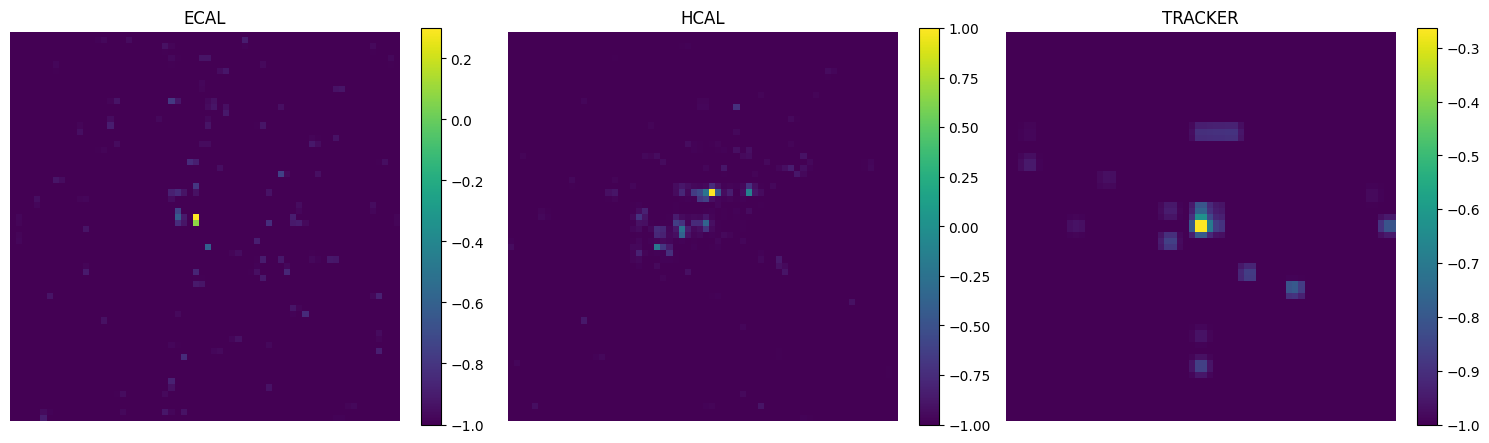

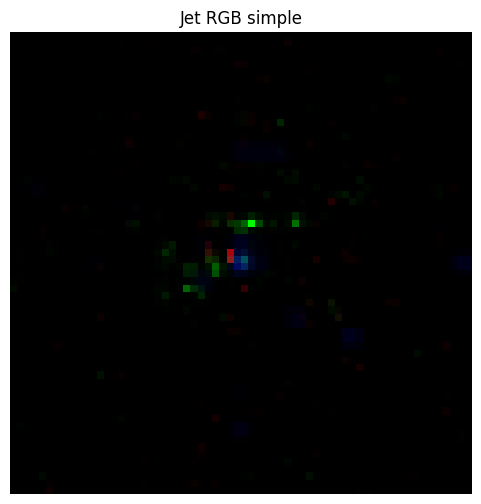

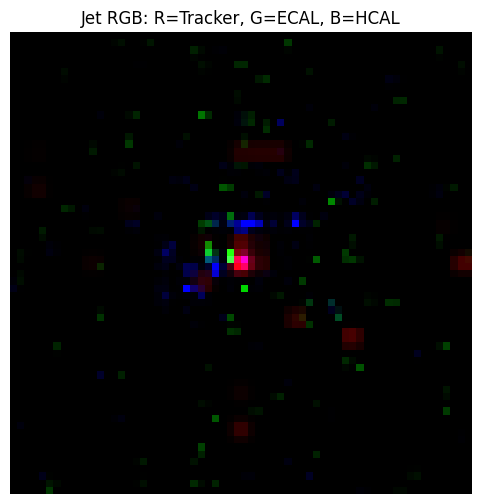



DATASET
Total dataset: 139306
Train dataset: 10000
Test dataset : 2500


BATCH
x_batch: torch.Size([16, 3, 64, 64])
y_batch: torch.Size([16])
batch min : -1.0
batch max : 1.0
batch mean: -0.9963786602020264
batch std : 0.046804279088974


In [8]:
file_path = 'Diffusion_jets_procesados_por_canal.hdf5'
full_dataset = JetsDataset(file_path)
img, label = full_dataset[0]

inspeccionar_imagen(img, label)
visualizar_canales(img)
visualizar_rgb_simple(img)
visualizar_rgb_jet(img)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset_full, test_dataset_full = random_split(full_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
usar_subset_pequeno = True
train_small_size = 10000
test_small_size = 2500

if usar_subset_pequeno:
    train_dataset = Subset(train_dataset_full, range(min(train_small_size, len(train_dataset_full))))
    test_dataset = Subset(test_dataset_full, range(min(test_small_size, len(test_dataset_full))))
else:
    train_dataset = train_dataset_full
    test_dataset = test_dataset_full

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
x_batch, y_batch = next(iter(train_loader))

print('\n')
print('DATASET')
print('Total dataset:', len(full_dataset))
print('Train dataset:', len(train_dataset))
print('Test dataset :', len(test_dataset))
print('\n' )
print('BATCH')
print('x_batch:', x_batch.shape)
print('y_batch:', y_batch.shape)
print('batch min :', x_batch.min().item())
print('batch max :', x_batch.max().item())
print('batch mean:', x_batch.mean().item())
print('batch std :', x_batch.std().item())

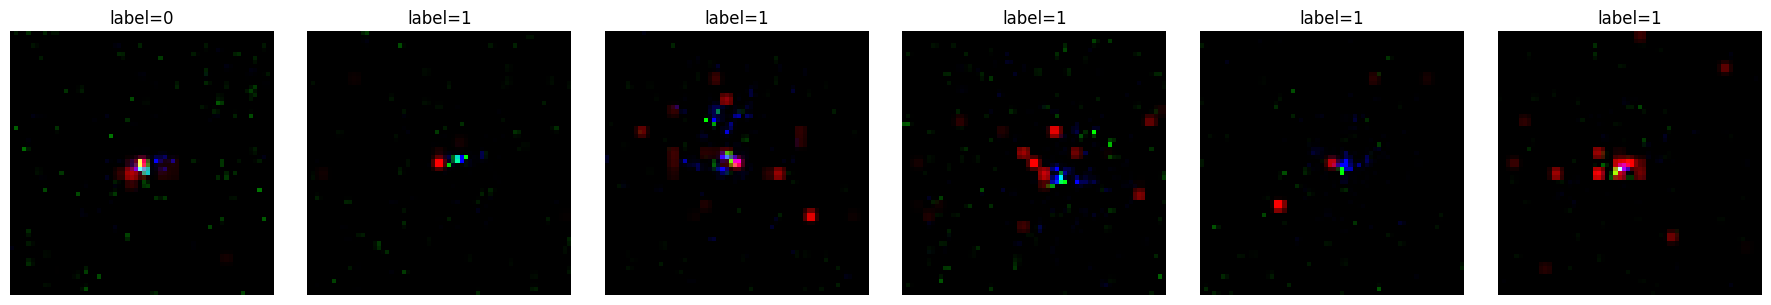

In [46]:
n = 6
fig, ax = plt.subplots(1, n, figsize=(3 * n, 3))

for i in range(n):
    img_i = x_batch[i].detach().cpu()
    img01 = (img_i + 1.0) / 2.0
    img01 = img01.clamp(0, 1)
    img01 = img01[[2, 0, 1]]
    img_vis = img01.clone()

    for c in range(3):
        canal = img_vis[c]
        activos = canal[canal > 1e-06]

        if activos.numel() > 0:
            vmax = torch.quantile(activos, 0.99)
            img_vis[c] = canal / (vmax + 1e-08)

    img_vis = img_vis.clamp(0, 1)
    img_rgb = img_vis.permute(1, 2, 0).numpy()
    ax[i].imshow(img_rgb, origin='lower')
    ax[i].set_title(f'label={y_batch[i].item()}')
    ax[i].axis('off')

plt.tight_layout()
plt.show()

Total de imágenes revisadas: 10000

MÁXIMOS POR IMAGEN
Máximo absoluto : 1.000000
Máximo promedio : 0.934415
Percentil 99    : 1.000000
Percentil 99.9  : 1.000000

PÍXELES ACTIVOS POR IMAGEN
Promedio        : 567.97
Mediana         : 550.00
Percentil 99    : 1028.00

SUMA TOTAL POR IMAGEN
Suma promedio   : 25.033385
Suma mediana    : 24.063066
Percentil 99    : 45.699089


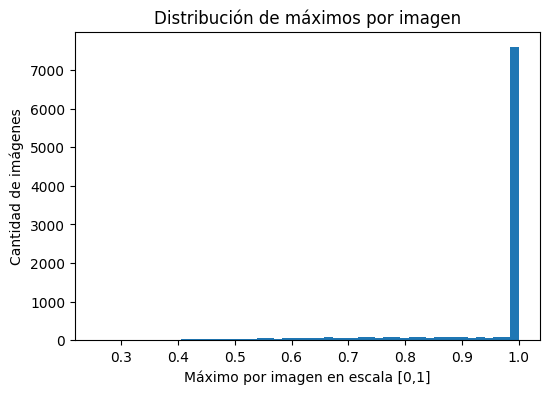

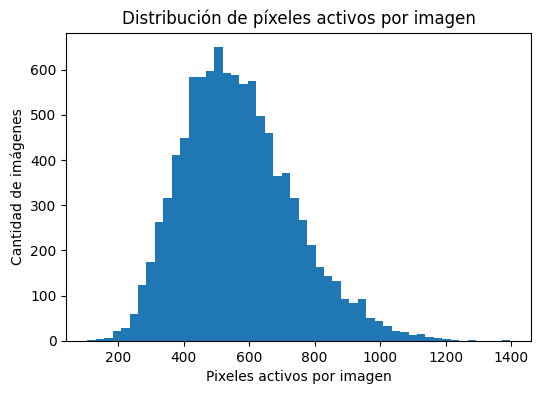

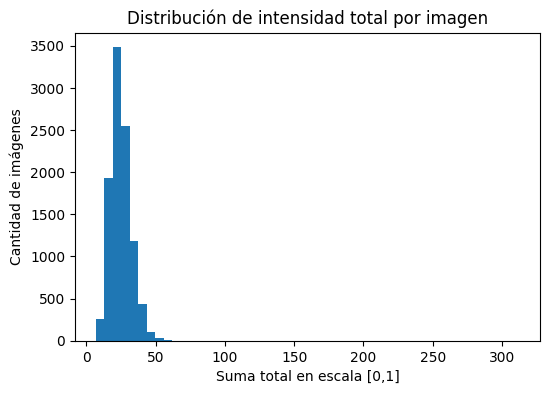

In [6]:
buscador_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
todos_los_maximos = []
todos_los_pixeles_activos = []
todos_los_sumas = []

with torch.no_grad():
    for imagenes, labels in buscador_loader:
        imagenes_01 = (imagenes + 1.0) / 2.0
        imagenes_01 = imagenes_01.clamp(0, 1)
        maximos_lote = imagenes_01.amax(dim=(1, 2, 3))
        pixeles_activos_lote = (imagenes_01 > 0.0001).sum(dim=(1, 2, 3))
        sumas_lote = imagenes_01.sum(dim=(1, 2, 3))

        todos_los_maximos.extend(maximos_lote.cpu().tolist())
        todos_los_pixeles_activos.extend(pixeles_activos_lote.cpu().tolist())
        todos_los_sumas.extend(sumas_lote.cpu().tolist())

todos_los_maximos = np.array(todos_los_maximos)
todos_los_pixeles_activos = np.array(todos_los_pixeles_activos)
todos_los_sumas = np.array(todos_los_sumas)

print(f'Total de imágenes revisadas: {len(todos_los_maximos)}')
print('\nMÁXIMOS POR IMAGEN')
print(f'Máximo absoluto : {todos_los_maximos.max():.6f}')
print(f'Máximo promedio : {todos_los_maximos.mean():.6f}')
print(f'Percentil 99    : {np.percentile(todos_los_maximos, 99):.6f}')
print(f'Percentil 99.9  : {np.percentile(todos_los_maximos, 99.9):.6f}')
print('\nPÍXELES ACTIVOS POR IMAGEN')
print(f'Promedio        : {todos_los_pixeles_activos.mean():.2f}')
print(f'Mediana         : {np.median(todos_los_pixeles_activos):.2f}')
print(f'Percentil 99    : {np.percentile(todos_los_pixeles_activos, 99):.2f}')
print('\nSUMA TOTAL POR IMAGEN')
print(f'Suma promedio   : {todos_los_sumas.mean():.6f}')
print(f'Suma mediana    : {np.median(todos_los_sumas):.6f}')
print(f'Percentil 99    : {np.percentile(todos_los_sumas, 99):.6f}')

plt.figure(figsize=(6, 4))
plt.hist(todos_los_maximos, bins=50)
plt.title('Distribución de máximos por imagen')
plt.xlabel('Máximo por imagen en escala [0,1]')
plt.ylabel('Cantidad de imágenes')
plt.show()
plt.figure(figsize=(6, 4))
plt.hist(todos_los_pixeles_activos, bins=50)
plt.title('Distribución de píxeles activos por imagen')
plt.xlabel('Pixeles activos por imagen')
plt.ylabel('Cantidad de imágenes')
plt.show()
plt.figure(figsize=(6, 4))
plt.hist(todos_los_sumas, bins=50)
plt.title('Distribución de intensidad total por imagen')
plt.xlabel('Suma total en escala [0,1]')
plt.ylabel('Cantidad de imágenes')
plt.show()

In [48]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

## Flow Matching Scheduler and Sampling

Flow Matching defines the linear path $x_{\tau}=(1-\tau)z+\tau x_0$, where $\tau=0$ corresponds to Gaussian noise and $\tau=1$ to the data. The UNet learns the velocity field with target $v=x_0-z$, and new jets are generated by integrating this field from noise to data using Euler steps.


In [49]:
class FlowMatchingScheduler:

    def __init__(self, num_timesteps, device):
        if num_timesteps < 2:
            raise ValueError('num_timesteps debe ser al menos 2.')

        self.num_timesteps = num_timesteps
        self.device = device
        self.inference_timesteps = None

    def _to_continuous_time(self, t):
        if not isinstance(t, torch.Tensor):
            t = torch.tensor(t, device=self.device, dtype=torch.float32)

        t = t.to(device=self.device, dtype=torch.float32)
        tau = t / float(self.num_timesteps - 1)

        return torch.clamp(tau, 0.0, 1.0)

    def _expand_time(self, t, x_shape):
        tau = self._to_continuous_time(t)

        if tau.dim() == 0:
            tau = tau[None]

        return tau.view(tau.shape[0], *[1] * (len(x_shape) - 1))

    def sample_timesteps(self, batch_size):
        return torch.rand((batch_size,), device=self.device) * float(self.num_timesteps - 1)

    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)

        tau = self._expand_time(t, x0.shape)
        x_t = (1.0 - tau) * noise + tau * x0

        return (x_t, noise)

    def get_velocity_target(self, x0, noise):
        return x0 - noise

    def predict_x0(self, x_t, velocity_pred, t, clip_x0=False):
        tau = self._expand_time(t, x_t.shape)
        x0_pred = x_t + (1.0 - tau) * velocity_pred

        if clip_x0:
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        return x0_pred

    def predict_noise(self, x_t, velocity_pred, t):
        tau = self._expand_time(t, x_t.shape)
        noise_pred = x_t - tau * velocity_pred

        return noise_pred

    def set_timesteps(self, num_inference_steps):
        if num_inference_steps < 1:
            raise ValueError('num_inference_steps debe ser al menos 1.')

        timesteps = torch.linspace(0.0, float(self.num_timesteps - 1), num_inference_steps + 1, device=self.device)
        self.inference_timesteps = timesteps

        return timesteps

    def step_euler(self, x_t, velocity_pred, t, t_next):
        tau = self._to_continuous_time(t)
        tau_next = self._to_continuous_time(t_next)
        dt = tau_next - tau

        if dt.dim() == 0:
            dt = dt.view(1, *[1] * (x_t.dim() - 1))
        else:
            dt = dt.view(dt.shape[0], *[1] * (x_t.dim() - 1))

        x_next = x_t + dt * velocity_pred

        return x_next

    def sample_next_timestep(self, x_t, velocity_pred, t, t_next, clip_x0=False):
        x0_pred = self.predict_x0(x_t=x_t, velocity_pred=velocity_pred, t=t, clip_x0=clip_x0)
        x_next = self.step_euler(x_t=x_t, velocity_pred=velocity_pred, t=t, t_next=t_next)

        return (x_next, x0_pred)

In [51]:
import math

import torch

import torch.nn as nn

import torch.nn.functional as F


def get_num_groups(channels, max_groups=8):
    for g in reversed(range(1, max_groups + 1)):
        if channels % g == 0:
            return g

    return 1


def sinusoidal_time_embedding(timesteps, dim):
    if timesteps.dim() == 0:
        timesteps = timesteps[None]

    timesteps = timesteps.float()
    half_dim = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=timesteps.device).float() / max(half_dim - 1, 1))
    args = timesteps[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))

    return emb


class TimeEmbedding(nn.Module):
    def __init__(self, t_emb_dim):
        super().__init__()

        self.t_emb_dim = t_emb_dim

        self.mlp = nn.Sequential(
            nn.Linear(t_emb_dim, 4 * t_emb_dim),
            nn.SiLU(),
            nn.Linear(4 * t_emb_dim, t_emb_dim)
        )

    def forward(self, t):
        t_emb = sinusoidal_time_embedding(t, self.t_emb_dim)

        return self.mlp(t_emb)

In [52]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, dropout=0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(get_num_groups(in_channels), in_channels)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, 2 * out_channels)
        )

        self.norm2 = nn.GroupNorm(get_num_groups(out_channels), out_channels)
        self.dropout = nn.Dropout(dropout)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.time_proj(t_emb)
        scale, shift = scale_shift[:, :, None, None].chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1.0 + scale) + shift
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual

In [53]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        assert channels % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = channels // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.GroupNorm(get_num_groups(channels), channels)
        self.qkv = nn.Conv2d(channels, 3 * channels, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        residual = x

        b, c, h, w = x.shape
        x = self.norm(x)

        q, k, v = self.qkv(x).chunk(3, dim=1)

        q = q.reshape(b, self.num_heads, self.head_dim, h * w)
        k = k.reshape(b, self.num_heads, self.head_dim, h * w)
        v = v.reshape(b, self.num_heads, self.head_dim, h * w)

        attn = torch.einsum("bhcn,bhcm->bhnm", q, k) * self.scale
        attn = attn.softmax(dim=-1)

        out = torch.einsum("bhnm,bhcm->bhcn", attn, v)
        out = out.reshape(b, c, h, w)

        return residual + self.proj(out)

In [54]:
class DownBlockStrong(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        t_emb_dim,
        use_attention=False,
        dropout=0.0
    ):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.downsample = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t_emb, do_downsample=True):
        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        skip = x

        if do_downsample:
            x = self.downsample(x)

        return x, skip

In [55]:
class MidBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads=4):
        super().__init__()

        self.resnet1 = ResidualBlock(in_channels, out_channels, t_emb_dim)
        self.attn = AttentionBlock(out_channels, num_heads)
        self.resnet2 = ResidualBlock(out_channels, out_channels, t_emb_dim)

    def forward(self, x, t_emb):

        x = self.resnet1(x, t_emb)
        x = self.attn(x)

        return self.resnet2(x, t_emb)

In [56]:
class UpBlockStrong(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        t_emb_dim,
        use_attention=False,
        dropout=0.0
    ):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels + skip_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.upsample = nn.ConvTranspose2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, skip, t_emb, do_upsample=True):
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")

        x = torch.cat([x, skip], dim=1)

        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        if do_upsample:
            x = self.upsample(x)

        return x

In [57]:
class UNET(nn.Module):
    def __init__(
        self,
        im_channels=3,
        base_channels=64,
        channel_mults=(1, 2, 4, 4),
        t_emb_dim=256,
        img_size=64,
        attn_resolutions=(16, 8),
        dropout=0.0
    ):
        super().__init__()

        self.img_size = img_size
        self.attn_resolutions = attn_resolutions

        self.time_mlp = TimeEmbedding(t_emb_dim)

        self.conv_in = nn.Conv2d(
            im_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        channels = [base_channels * m for m in channel_mults]

        self.downs = nn.ModuleList()

        in_channels = base_channels
        resolution = img_size

        for i, out_channels in enumerate(channels):
            use_attention = resolution in attn_resolutions

            self.downs.append(
                DownBlockStrong(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )

            in_channels = out_channels

            if i != len(channels) - 1:
                resolution //= 2

        mid_channels = channels[-1]

        self.mid1 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.mid_attn = AttentionBlock(mid_channels)

        self.mid2 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.ups = nn.ModuleList()

        reversed_channels = list(reversed(channels))
        resolutions = [img_size // (2 ** i) for i in range(len(channels))]
        reversed_resolutions = list(reversed(resolutions))

        in_channels = mid_channels

        for i, skip_channels in enumerate(reversed_channels):
            is_last = i == len(reversed_channels) - 1

            if i < len(reversed_channels) - 1:
                out_channels = reversed_channels[i + 1]
            else:
                out_channels = base_channels

            use_attention = reversed_resolutions[i] in attn_resolutions

            self.ups.append(
                UpBlockStrong(
                    in_channels=in_channels,
                    skip_channels=skip_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )

            in_channels = out_channels

        self.norm_out = nn.GroupNorm(
            get_num_groups(base_channels),
            base_channels
        )

        self.conv_out = nn.Conv2d(
            base_channels,
            im_channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x = self.conv_in(x)

        skips = []

        for i, down in enumerate(self.downs):
            do_downsample = i != len(self.downs) - 1
            x, skip = down(x, t_emb, do_downsample=do_downsample)
            skips.append(skip)

        x = self.mid1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid2(x, t_emb)

        for i, up in enumerate(self.ups):
            skip = skips.pop()
            do_upsample = i != len(self.ups) - 1
            x = up(x, skip, t_emb, do_upsample=do_upsample)

        x = self.norm_out(x)
        x = F.silu(x)

        return self.conv_out(x)

In [ ]:
configuracion_inicial = {
    'diffusion_params': {'num_timesteps': 1000, 'beta_s': 0.0001, 'beta_e': 0.02},
    'model_params': {'im_channels': 3, 'im_size': 64},
    'train_params': {'task_name': 'default', 'batch_size': 16, 'num_epochs': 5, 'num_samples': 100, 'num_grid_rows': 10, 'lr': 0.0001},
}

## Sparse Velocity Training

The objective combines the global velocity error with penalties on active pixels, background suppression, and total deposited energy. These additional terms prevent the highly sparse calorimeter background from dominating the optimization and help preserve the physically relevant jet response.


In [59]:
def sparse_flow_matching_velocity_loss_background_energy(
    velocity_pred, target_velocity, x_t, x0, t, scheduler, active_thr=-0.99, active_lambda=1.0,
    background_lambda=1.0, energy_lambda=1.0, bg_margin_01=0.0, eps=1e-08,
):
    error_velocity = (velocity_pred - target_velocity) ** 2
    loss_global = error_velocity.mean()
    active_mask = x0 > active_thr
    background_mask = x0 <= active_thr

    if active_mask.any():
        loss_active = error_velocity[active_mask].mean()
    else:
        loss_active = x0.new_zeros(())

    x0_pred = scheduler.predict_x0(x_t=x_t, velocity_pred=velocity_pred, t=t, clip_x0=False)
    x0_pred_01 = (x0_pred + 1.0) / 2.0
    x0_real_01 = (x0 + 1.0) / 2.0
    x0_pred_pos = torch.relu(x0_pred_01)

    if background_mask.any():
        background_excess = torch.relu(x0_pred_01[background_mask] - bg_margin_01)
        loss_background = background_excess.mean()
    else:
        loss_background = x0.new_zeros(())

    energy_pred = x0_pred_pos.sum(dim=(1, 2, 3))
    energy_real = x0_real_01.sum(dim=(1, 2, 3))
    loss_energy = F.mse_loss(torch.log1p(energy_pred), torch.log1p(energy_real))
    loss = loss_global + active_lambda * loss_active + background_lambda * loss_background + energy_lambda * loss_energy

    return (loss, loss_global, loss_active, loss_background, loss_energy)

In [60]:
CANAL_NOMBRES = ['ECAL', 'HCAL', 'TRACKER']


@torch.no_grad()
def to_01(x):
    x = x.detach()

    if x.min().item() < -0.05:
        x = (x + 1.0) / 2.0

    return x.clamp(0.0, 1.0)


@torch.no_grad()
def wasserstein_xy_metric(x_pred, x_real, eps=1e-08):
    x_pred = to_01(x_pred)
    x_real = to_01(x_real)
    proj_x_pred = x_pred.sum(dim=1).sum(dim=1)
    proj_x_real = x_real.sum(dim=1).sum(dim=1)
    proj_y_pred = x_pred.sum(dim=1).sum(dim=2)
    proj_y_real = x_real.sum(dim=1).sum(dim=2)
    px_pred = proj_x_pred / (proj_x_pred.sum(dim=-1, keepdim=True) + eps)
    px_real = proj_x_real / (proj_x_real.sum(dim=-1, keepdim=True) + eps)
    py_pred = proj_y_pred / (proj_y_pred.sum(dim=-1, keepdim=True) + eps)
    py_real = proj_y_real / (proj_y_real.sum(dim=-1, keepdim=True) + eps)
    cdf_x_pred = torch.cumsum(px_pred, dim=-1)
    cdf_x_real = torch.cumsum(px_real, dim=-1)
    cdf_y_pred = torch.cumsum(py_pred, dim=-1)
    cdf_y_real = torch.cumsum(py_real, dim=-1)
    w1_x = torch.sum(torch.abs(cdf_x_pred - cdf_x_real), dim=-1).mean()
    w1_y = torch.sum(torch.abs(cdf_y_pred - cdf_y_real), dim=-1).mean()

    return {'w1_x': w1_x.item(), 'w1_y': w1_y.item(), 'w1_xy': (w1_x + w1_y).item()}


class JetRadialProfiler(nn.Module):

    def __init__(self, img_size=64, num_bins=32, sigma=1.0):
        super().__init__()
        self.num_bins = num_bins
        self.sigma = sigma
        y = torch.arange(img_size).float()
        x = torch.arange(img_size).float()
        grid_y, grid_x = torch.meshgrid(y, x, indexing='ij')
        cy = img_size / 2 - 0.5
        cx = img_size / 2 - 0.5
        dist_matrix = torch.sqrt((grid_y - cy) ** 2 + (grid_x - cx) ** 2)
        max_r = float(dist_matrix.max().item())
        bin_centers = torch.linspace(0.0, max_r, num_bins)

        self.register_buffer('dist_matrix', dist_matrix.view(1, 1, img_size, img_size))
        self.register_buffer('bin_centers', bin_centers.view(1, 1, 1, 1, num_bins))

    def profiles(self, x):
        x = to_01(x)
        B, C, H, W = x.shape
        dists = self.dist_matrix.expand(B, C, H, W).unsqueeze(-1)
        weights = torch.exp(-0.5 * ((dists - self.bin_centers) / self.sigma) ** 2)
        profile = (x.unsqueeze(-1) * weights).sum(dim=(2, 3))
        profile = profile / (profile.sum(dim=-1, keepdim=True) + 1e-08)

        return profile

    def forward(self, x_pred, x_real):
        profile_pred = self.profiles(x_pred)
        profile_real = self.profiles(x_real)

        return F.mse_loss(profile_pred, profile_real)


@torch.no_grad()
def jet_observables(x, active_thr=0.0001, eps=1e-08):
    x = to_01(x)
    energy = x.sum(dim=(1, 2, 3))
    active_frac = (x > active_thr).float().mean(dim=(1, 2, 3))
    max_intensity = x.amax(dim=(1, 2, 3))
    participation_ratio = energy ** 2 / ((x ** 2).sum(dim=(1, 2, 3)) + eps)

    return {'energy': energy, 'active_frac': active_frac, 'max_intensity': max_intensity, 'participation_ratio': participation_ratio}


def w1_samples(a, b, num_quantiles=1000):
    a = a.detach().float().cpu().numpy().reshape(-1)
    b = b.detach().float().cpu().numpy().reshape(-1)
    nq = min(num_quantiles, len(a), len(b))
    qs = np.linspace(0.0, 1.0, nq)
    qa = np.quantile(a, qs)
    qb = np.quantile(b, qs)

    return float(np.mean(np.abs(qa - qb)))


@torch.no_grad()
def evaluar_reconstruccion_jets(x_rec, x_real, active_thr=0.0001, num_bins=32):
    x_rec = to_01(x_rec)
    x_real = to_01(x_real)
    device_metric = x_real.device
    metricas = {}
    metricas['mse_total'] = F.mse_loss(x_rec, x_real).item()
    active_mask = x_real > active_thr

    if active_mask.sum() > 0:
        metricas['mse_activo_real'] = ((x_rec - x_real) ** 2)[active_mask].mean().item()
    else:
        metricas['mse_activo_real'] = np.nan

    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device_metric)
    metricas['ssim'] = ssim_metric(x_rec, x_real).item()
    metricas.update(wasserstein_xy_metric(x_rec, x_real))
    radial = JetRadialProfiler(img_size=x_real.shape[-1], num_bins=num_bins, sigma=1.0).to(device_metric)
    metricas['radial_mse'] = radial(x_rec, x_real).item()
    obs_real = jet_observables(x_real, active_thr=active_thr)
    obs_rec = jet_observables(x_rec, active_thr=active_thr)

    for key in obs_real:
        metricas[f'{key}_real_mean'] = obs_real[key].mean().item()
        metricas[f'{key}_rec_mean'] = obs_rec[key].mean().item()

    for c, nombre in enumerate(CANAL_NOMBRES):
        xr_c = x_real[:, c:c + 1]
        xp_c = x_rec[:, c:c + 1]
        metricas[f'mse_{nombre}'] = F.mse_loss(xp_c, xr_c).item()
        w1_c = wasserstein_xy_metric(xp_c, xr_c)
        metricas[f'w1_xy_{nombre}'] = w1_c['w1_xy']

    return metricas


@torch.no_grad()
def evaluar_generacion_jets(x_gen, x_real_ref, active_thr=0.0001, num_bins=32):
    x_gen = to_01(x_gen)
    x_real_ref = to_01(x_real_ref).to(x_gen.device)
    device_metric = x_gen.device
    metricas = {}
    obs_real = jet_observables(x_real_ref, active_thr=active_thr)
    obs_gen = jet_observables(x_gen, active_thr=active_thr)
    metricas['E_w1'] = w1_samples(obs_gen['energy'], obs_real['energy'])
    metricas['active_frac_w1'] = w1_samples(obs_gen['active_frac'], obs_real['active_frac'])
    metricas['max_intensity_w1'] = w1_samples(obs_gen['max_intensity'], obs_real['max_intensity'])
    metricas['participation_ratio_w1'] = w1_samples(obs_gen['participation_ratio'], obs_real['participation_ratio'])
    metricas['energy_real_mean'] = obs_real['energy'].mean().item()
    metricas['energy_gen_mean'] = obs_gen['energy'].mean().item()
    metricas['active_frac_real_mean'] = obs_real['active_frac'].mean().item()
    metricas['active_frac_gen_mean'] = obs_gen['active_frac'].mean().item()
    metricas['max_real_mean'] = obs_real['max_intensity'].mean().item()
    metricas['max_gen_mean'] = obs_gen['max_intensity'].mean().item()
    metricas['pr_real_mean'] = obs_real['participation_ratio'].mean().item()
    metricas['pr_gen_mean'] = obs_gen['participation_ratio'].mean().item()
    metricas['pr_ratio'] = metricas['pr_gen_mean'] / (metricas['pr_real_mean'] + 1e-08)
    metricas['gen_max_to_real_max'] = x_gen.amax().item() / (x_real_ref.amax().item() + 1e-08)
    radial = JetRadialProfiler(img_size=x_real_ref.shape[-1], num_bins=num_bins, sigma=1.0).to(device_metric)
    prof_real = radial.profiles(x_real_ref).mean(dim=0)
    prof_gen = radial.profiles(x_gen).mean(dim=0)
    metricas['radial_l2'] = torch.sqrt(torch.mean((prof_gen - prof_real) ** 2)).item()
    metricas['radial_l2_log'] = torch.sqrt(torch.mean((torch.log10(prof_gen + 1e-08) - torch.log10(prof_real + 1e-08)) ** 2)).item()

    return metricas


@torch.no_grad()
def obtener_reales_01(loader, n, device):
    xs = []
    total = 0

    for im, _ in loader:
        xs.append(im.float())
        total += im.shape[0]

        if total >= n:
            break

    x = torch.cat(xs, dim=0)[:n].to(device)

    return to_01(x)


def mostrar_metricas(metricas, titulo='Métricas'):
    print('\n' + '=' * 60)
    print(titulo)
    print('=' * 60)

    df = pd.DataFrame.from_dict(metricas, orient='index', columns=['valor'])
    display(df)

In [ ]:
def print_tensor_stats(name, x):
    print(f'{name} min/max/mean/std:', x.min().item(), x.max().item(), x.mean().item(), x.std().item())


def train_flow_matching_background_energy():
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    diffusion_config = configuracion_inicial['diffusion_params']
    model_config = configuracion_inicial['model_params']
    train_config = configuracion_inicial['train_params']
    scheduler = FlowMatchingScheduler(num_timesteps=diffusion_config['num_timesteps'], device=device)

    print('SCHEDULER USADO PARA FLOW MATCHING')
    print('VELOCITY + BACKGROUND + ENERGY LOSS')
    print('num_timesteps:', scheduler.num_timesteps)
    print('Tiempo para el modelo:')
    print(f't_model ∈ [0, {scheduler.num_timesteps - 1}]')
    print('Tiempo interno de Flow Matching:')
    print('tau ∈ [0, 1]')
    print('tau = 0  ruido puro')
    print('tau = 1 imagen real')

    model = UNET(model_config['im_channels']).to(device)
    model.train()
    optimizer = Adam(model.parameters(), lr=train_config['lr'])
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)
    num_epochs = train_config['num_epochs']
    history = {'loss': [], 'global': [], 'active': [], 'background': [], 'energy': [], 'ssim': [], 'mse_x0_pred': [], 'mse_fondo': [], 'mse_activo': []}

    for epoch_idx in range(num_epochs):
        losses = []
        global_losses = []
        active_losses = []
        background_losses = []
        energy_losses = []
        mse_x0_scores = []
        mse_fondo_scores = []
        mse_activo_scores = []

        ssim_metric.reset()
        start_time = time.time()

        for step, (im, _) in enumerate(train_loader):
            im = im.float().to(device)
            optimizer.zero_grad()
            noise = torch.randn_like(im)
            t = scheduler.sample_timesteps(batch_size=im.shape[0])
            x_t, noise = scheduler.add_noise(x0=im, t=t, noise=noise)
            target_velocity = scheduler.get_velocity_target(x0=im, noise=noise)
            velocity_pred = model(x_t, t)
            loss, loss_global, loss_active, loss_background, loss_energy = sparse_flow_matching_velocity_loss_background_energy(
                velocity_pred=velocity_pred, target_velocity=target_velocity, x_t=x_t, x0=im, t=t,
                scheduler=scheduler, active_thr=-0.99, active_lambda=5.0, background_lambda=100.0,
                energy_lambda=10.0, bg_margin_01=0.0,
            )

            if epoch_idx == 0 and step == 0:
                tau = scheduler._to_continuous_time(t)
                print('\n')
                print('REVISIÓN DEL PRIMER BATCH')
                print('im shape:', im.shape)
                print_tensor_stats('im', im)
                print('\nTiempos usados por la U-Net:')
                print('t min:', t.min().item())
                print('t max:', t.max().item())
                print('t mean:', t.mean().item())
                print('\nTiempos internos de Flow Matching:')
                print('tau min:', tau.min().item())
                print('tau max:', tau.max().item())
                print('tau mean:', tau.mean().item())
                print('\nShapes:')
                print('x_t shape:', x_t.shape)
                print('noise shape:', noise.shape)
                print('target_velocity shape:', target_velocity.shape)
                print('velocity_pred shape:', velocity_pred.shape)
                print()
                print_tensor_stats('x_t', x_t)
                print_tensor_stats('noise', noise)
                print_tensor_stats('target_velocity', target_velocity)
                print_tensor_stats('velocity_pred', velocity_pred)
                print('\nComponentes iniciales de la loss:')
                print('Loss total:', loss.item())
                print('Global:', loss_global.item())
                print('Active:', loss_active.item())
                print('Background:', loss_background.item())
                print('Energy:', loss_energy.item())

                with torch.no_grad():
                    error_velocity = (velocity_pred - target_velocity) ** 2
                    active_mask = im > -0.99
                    background_mask = im <= -0.99

                    if background_mask.any():
                        mse_fondo_inicial = error_velocity[background_mask].mean().item()
                    else:
                        mse_fondo_inicial = float('nan')

                    if active_mask.any():
                        mse_activo_inicial = error_velocity[active_mask].mean().item()
                    else:
                        mse_activo_inicial = float('nan')

                    x0_pred_inicial = scheduler.predict_x0(x_t=x_t, velocity_pred=velocity_pred, t=t, clip_x0=False)
                    x0_pred_inicial_clipped = torch.clamp(x0_pred_inicial, -1.0, 1.0)
                    mse_x0_inicial = torch.mean((x0_pred_inicial_clipped - im) ** 2).item()

                    print('MSE velocidad fondo:', mse_fondo_inicial)
                    print('MSE velocidad activo:', mse_activo_inicial)
                    print('Fracción de píxeles activos:', active_mask.float().mean().item())
                    print('MSE x0_pred inicial:', mse_x0_inicial)

            with torch.no_grad():
                error_velocity = (velocity_pred - target_velocity) ** 2
                active_mask = im > -0.99
                background_mask = im <= -0.99

                if background_mask.any():
                    mse_fondo = error_velocity[background_mask].mean().item()
                else:
                    mse_fondo = np.nan

                if active_mask.any():
                    mse_activo = error_velocity[active_mask].mean().item()
                else:
                    mse_activo = np.nan

                x0_pred = scheduler.predict_x0(x_t=x_t, velocity_pred=velocity_pred, t=t, clip_x0=False)
                x0_pred_metric = torch.clamp(x0_pred, -1.0, 1.0)
                mse_x0 = torch.mean((x0_pred_metric - im) ** 2).item()

                ssim_metric.update(x0_pred_metric, im)
                mse_fondo_scores.append(mse_fondo)
                mse_activo_scores.append(mse_activo)
                mse_x0_scores.append(mse_x0)

            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            global_losses.append(loss_global.item())
            active_losses.append(loss_active.item())
            background_losses.append(loss_background.item())
            energy_losses.append(loss_energy.item())

        avg_loss = np.mean(losses)
        avg_global = np.mean(global_losses)
        avg_active = np.mean(active_losses)
        avg_background = np.mean(background_losses)
        avg_energy = np.mean(energy_losses)
        avg_mse_x0 = np.mean(mse_x0_scores)
        avg_mse_fondo = np.nanmean(mse_fondo_scores)
        avg_mse_activo = np.nanmean(mse_activo_scores)
        avg_ssim = ssim_metric.compute().item()
        elapsed = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']

        history['loss'].append(avg_loss)
        history['global'].append(avg_global)
        history['active'].append(avg_active)
        history['background'].append(avg_background)
        history['energy'].append(avg_energy)
        history['ssim'].append(avg_ssim)
        history['mse_x0_pred'].append(avg_mse_x0)
        history['mse_fondo'].append(avg_mse_fondo)
        history['mse_activo'].append(avg_mse_activo)
        print(
            f'Epoch: {epoch_idx + 1}/{num_epochs} | '
            f'LR: {current_lr:.6f} | '
            f'Loss: {avg_loss:.6f} | '
            f'Global: {avg_global:.6f} | '
            f'Active: {avg_active:.6f} | '
            f'Background: {avg_background:.6f} | '
            f'Energy: {avg_energy:.6f} | '
            f'SSIM: {avg_ssim:.6f} | '
            f'MSE x0: {avg_mse_x0:.6f} | '
            f'Time: {elapsed:.2f}s'
        )

    return (model, scheduler, history)

In [62]:
modelo_entrenado, scheduler, history_fm = train_flow_matching_background_energy()

SCHEDULER USADO PARA FLOW MATCHING
VELOCITY + BACKGROUND + ENERGY LOSS
num_timesteps: 1000
Tiempo para el modelo:
t_model ∈ [0, 999]
Tiempo interno de Flow Matching:
tau ∈ [0, 1]
tau = 0 -> ruido puro
tau = 1 -> imagen real

REVISIÓN DEL PRIMER BATCH
im shape: torch.Size([16, 3, 64, 64])
im min/max/mean/std: -1.0 1.0 -0.9967164993286133 0.043465036898851395

Tiempos usados por la U-Net:
t min: 64.7838134765625
t max: 991.5090942382812
t mean: 451.76715087890625

Tiempos internos de Flow Matching:
tau min: 0.06484866142272949
tau max: 0.9925016164779663
tau mean: 0.4522193670272827

Shapes:
x_t shape: torch.Size([16, 3, 64, 64])
noise shape: torch.Size([16, 3, 64, 64])
target_velocity shape: torch.Size([16, 3, 64, 64])
velocity_pred shape: torch.Size([16, 3, 64, 64])

x_t min/max/mean/std: -4.047967433929443 3.3701562881469727 -0.4528564214706421 0.6995011568069458
noise min/max/mean/std: -4.259330749511719 4.354264736175537 -0.004456597846001387 1.0004546642303467
target_velocity min/m

In [63]:
def graficar_history_fm(history):
    epochs = np.arange(1, len(history['loss']) + 1)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history['loss'], marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Flow Matching training loss')
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history['ssim'], marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('SSIM')
    plt.title('SSIM de x0_pred vs x0')
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history['mse_x0_pred'], marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.title('MSE de x0_pred vs x0')
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history['mse_fondo'], marker='o', label='Fondo')
    plt.plot(epochs, history['mse_activo'], marker='o', label='Activo')
    plt.xlabel('Epoch')
    plt.ylabel('MSE velocity')
    plt.title('MSE en fondo vs píxeles activos')
    plt.legend()
    plt.grid(True)
    plt.show()

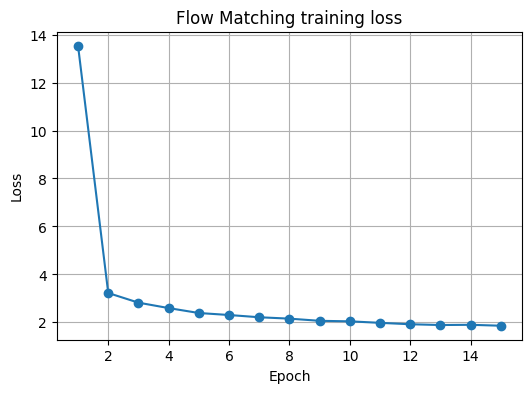

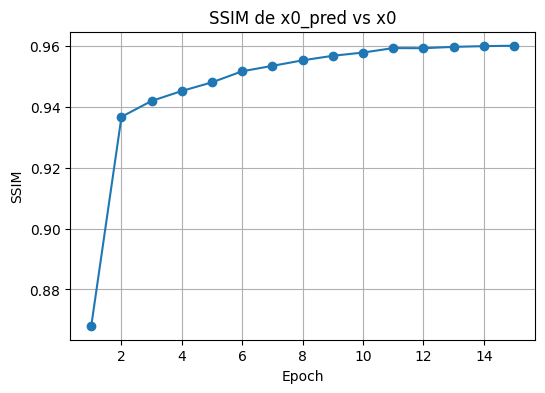

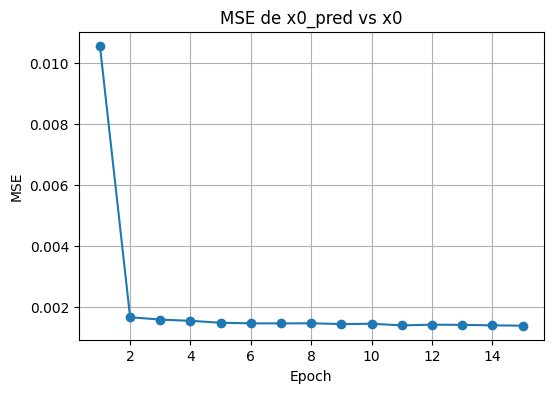

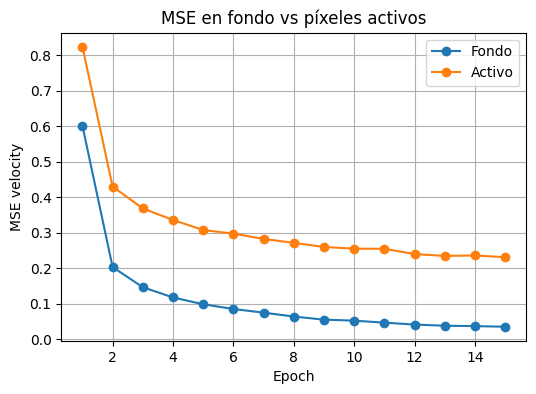

In [64]:
graficar_history_fm(history_fm)

In [65]:
@torch.no_grad()
def generar_jets_fm(model, scheduler, num_imagenes=4, shape=(3, 64, 64), num_steps=50, mostrar=True, max_mostrar=6, contrast=True):
    model.eval()
    device = next(model.parameters()).device
    x = torch.randn((num_imagenes, *shape), device=device)
    timesteps = scheduler.set_timesteps(num_inference_steps=num_steps)
    x0_pred_final = None

    for i in range(len(timesteps) - 1):
        t_curr = timesteps[i]
        t_next = timesteps[i + 1]
        t_batch = torch.full((num_imagenes,), float(t_curr.item()), device=device, dtype=torch.float32)
        velocity_pred = model(x, t_batch)
        x, x0_pred = scheduler.sample_next_timestep(x_t=x, velocity_pred=velocity_pred, t=t_curr, t_next=t_next, clip_x0=False)
        x0_pred_final = x0_pred

    x_final = torch.clamp(x, -1.0, 1.0)
    imgs = torch.clamp((x_final + 1.0) / 2.0, 0.0, 1.0).cpu()

    if mostrar:
        n_vis = min(num_imagenes, max_mostrar)
        fig, axes = plt.subplots(1, n_vis, figsize=(3 * n_vis, 3))

        if n_vis == 1:
            axes = [axes]

        for i in range(n_vis):
            img01 = imgs[i][[2, 0, 1]].clone()

            if contrast:
                img_vis = img01.clone()

                for c in range(3):
                    canal = img_vis[c]
                    activos = canal[canal > 1e-06]

                    if activos.numel() > 0:
                        vmax = torch.quantile(activos, 0.99)
                        img_vis[c] = canal / (vmax + 1e-08)

                img_vis = img_vis.clamp(0.0, 1.0)
            else:
                img_vis = img01

            img_rgb = img_vis.permute(1, 2, 0).numpy()
            axes[i].imshow(img_rgb, origin='lower')
            axes[i].set_title(f'FM gen ({num_steps} steps)')
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    return imgs

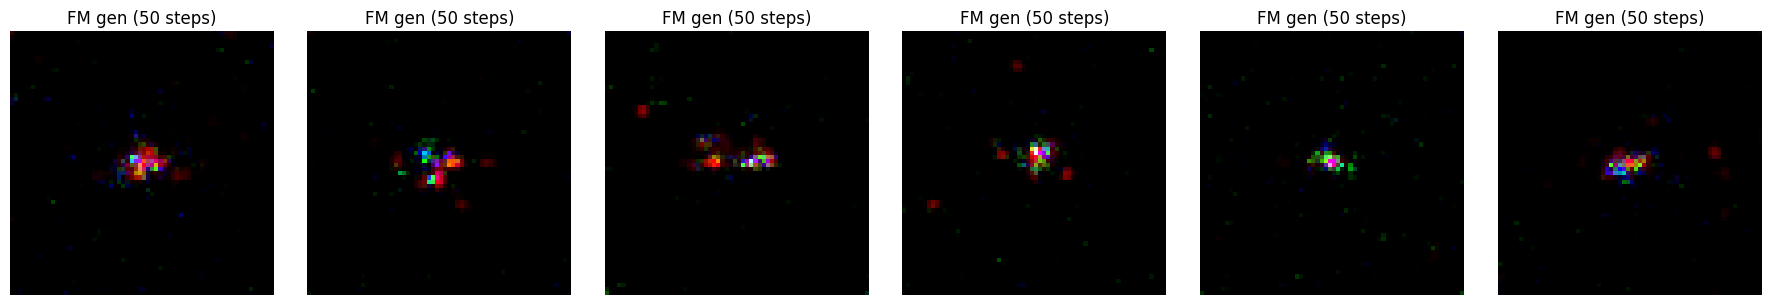

In [66]:
imgs = generar_jets_fm(modelo_entrenado, scheduler, num_imagenes=6, shape=(3, 64, 64), num_steps=50, mostrar=True, max_mostrar=6, contrast=True)

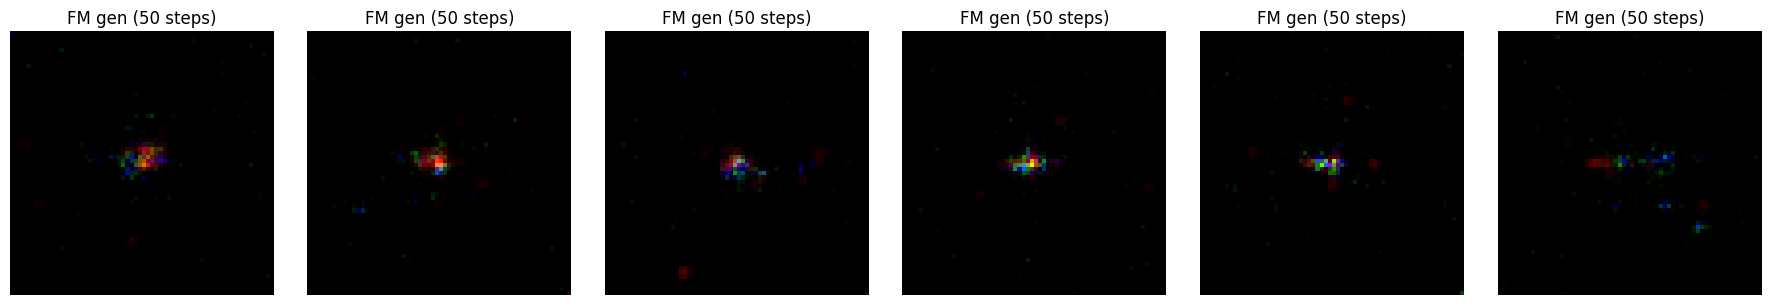

In [67]:
imgs = generar_jets_fm(modelo_entrenado, scheduler, num_imagenes=6, shape=(3, 64, 64), num_steps=50, mostrar=True, max_mostrar=6, contrast=False)

In [68]:
n_eval_gen = 128
jets_gen_eval = generar_jets_fm(modelo_entrenado, scheduler, num_imagenes=n_eval_gen, shape=(3, 64, 64), num_steps=50, mostrar=False, contrast=False)
jets_real_eval = obtener_reales_01(test_loader, n=n_eval_gen, device=device)
metricas_gen = evaluar_generacion_jets(x_gen=jets_gen_eval.to(device), x_real_ref=jets_real_eval, active_thr=0.0001, num_bins=32)

mostrar_metricas(metricas_gen, titulo='Generación desde cero Flow Matching')


Generación desde cero Flow Matching


,valor
E_w1,9.391921
active_frac_w1,0.019337
max_intensity_w1,0.036356
participation_ratio_w1,20.263630
energy_real_mean,25.535656
energy_gen_mean,34.927574
active_frac_real_mean,0.047497
active_frac_gen_mean,0.028159
max_real_mean,0.939186
max_gen_mean,0.935040


In [69]:
def jet_tensor_to_rgb_for_display(img_chw, channel_order=(2, 0, 1), contrast=True):
    img = img_chw[channel_order].clone()

    if contrast:
        for c in range(img.shape[0]):
            canal = img[c]
            activos = canal[canal > 1e-06]

            if activos.numel() > 0:
                vmax = torch.quantile(activos, 0.99)
                img[c] = canal / (vmax + 1e-08)

    img = img.clamp(0.0, 1.0)

    return img.permute(1, 2, 0).numpy()

In [70]:
@torch.no_grad()
def reconstruccion_iterativa_desde_xt_fm(model, scheduler, loader, device, t_start=500, n=4, num_steps=50, mostrar=True, contrast=True):
    model.eval()
    t_final = scheduler.num_timesteps - 1

    if not 0 <= t_start <= t_final:
        raise ValueError(f't_start debe estar entre 0 y {t_final}, pero se recibió {t_start}.')

    if num_steps < 1:
        raise ValueError('num_steps debe ser al menos 1.')

    tau_start = float(t_start) / float(t_final)
    x0, _ = next(iter(loader))
    x0 = x0[:n].float().to(device)
    n_real = x0.shape[0]
    noise = torch.randn_like(x0)
    t_start_tensor = torch.full((n_real,), float(t_start), device=device, dtype=torch.float32)
    x_t, noise_real = scheduler.add_noise(x0=x0, t=t_start_tensor, noise=noise)
    x = x_t.clone()
    timesteps = torch.linspace(float(t_start), float(t_final), steps=num_steps + 1, device=device, dtype=torch.float32)
    x0_pred_final = None

    for i in range(len(timesteps) - 1):
        t_curr = timesteps[i]
        t_next = timesteps[i + 1]
        t_batch = torch.full((n_real,), float(t_curr.item()), device=device, dtype=torch.float32)
        velocity_pred = model(x, t_batch)
        x, x0_pred = scheduler.sample_next_timestep(x_t=x, velocity_pred=velocity_pred, t=t_curr, t_next=t_next, clip_x0=False)
        x0_pred_final = x0_pred

    x_recon = torch.clamp(x, -1.0, 1.0)
    mse = torch.mean((x_recon - x0) ** 2).item()
    print('=' * 60)
    print(f'RECONSTRUCCIÓN FLOW MATCHING DESDE t_start={t_start}')
    print('=' * 60)
    print('num_timesteps:', scheduler.num_timesteps)
    print('t_start modelo:', t_start)
    print(f'tau_start normalizado: {tau_start:.6f}')
    print('num_steps integración:', num_steps)
    print('Número de puntos temporales:', len(timesteps))
    print(f'MSE reconstrucción: {mse:.6f}')

    x0_vis = torch.clamp((x0 + 1.0) / 2.0, 0.0, 1.0).cpu()
    xt_vis = torch.clamp((x_t + 1.0) / 2.0, 0.0, 1.0).cpu()
    recon_vis = torch.clamp((x_recon + 1.0) / 2.0, 0.0, 1.0).cpu()

    if mostrar:
        fig, axes = plt.subplots(n_real, 3, figsize=(9, 3 * n_real))

        if n_real == 1:
            axes = [axes]

        for i in range(n_real):
            img0 = x0_vis[i][[2, 0, 1]].clone()
            imgt = xt_vis[i][[2, 0, 1]].clone()
            imgr = recon_vis[i][[2, 0, 1]].clone()

            if contrast:
                imgs_tmp = []

                for img_tmp in [img0, imgt, imgr]:
                    img_vis = img_tmp.clone()

                    for c in range(3):
                        canal = img_vis[c]
                        activos = canal[canal > 1e-06]

                        if activos.numel() > 0:
                            vmax = torch.quantile(activos, 0.99)
                            img_vis[c] = canal / (vmax + 1e-08)

                    imgs_tmp.append(img_vis.clamp(0.0, 1.0))

                img0, imgt, imgr = imgs_tmp

            img0 = img0.permute(1, 2, 0).numpy()
            imgt = imgt.permute(1, 2, 0).numpy()
            imgr = imgr.permute(1, 2, 0).numpy()

            axes[i][0].imshow(img0, origin='lower')
            axes[i][0].set_title('Original')
            axes[i][0].axis('off')
            axes[i][1].imshow(imgt, origin='lower')
            axes[i][1].set_title(f'x_t, t={t_start}\ntau={tau_start:.3f}')
            axes[i][1].axis('off')
            axes[i][2].imshow(imgr, origin='lower')
            axes[i][2].set_title(f'Reconstrucción FM\n{num_steps} pasos')
            axes[i][2].axis('off')

        plt.tight_layout()
        plt.show()

    return {
        'x0': x0.detach().cpu(),
        'x_t': x_t.detach().cpu(),
        'noise': noise_real.detach().cpu(),
        'recon': x_recon.detach().cpu(),
        'x0_pred_last': x0_pred_final.detach().cpu() if x0_pred_final is not None else None,
        'x0_01': x0_vis,
        'xt_01': xt_vis,
        'recon_01': recon_vis,
        't_start': t_start,
        'tau_start': tau_start,
        'num_steps': num_steps,
        'timesteps': timesteps.detach().cpu(),
        'mse_original': mse,
    }

RECONSTRUCCIÓN FLOW MATCHING DESDE t_start=0.95
num_timesteps: 1000
t_start modelo: 0.95
tau_start normalizado: 0.000951
num_steps integración: 50
Número de puntos temporales: 51
MSE reconstrucción: 0.005353


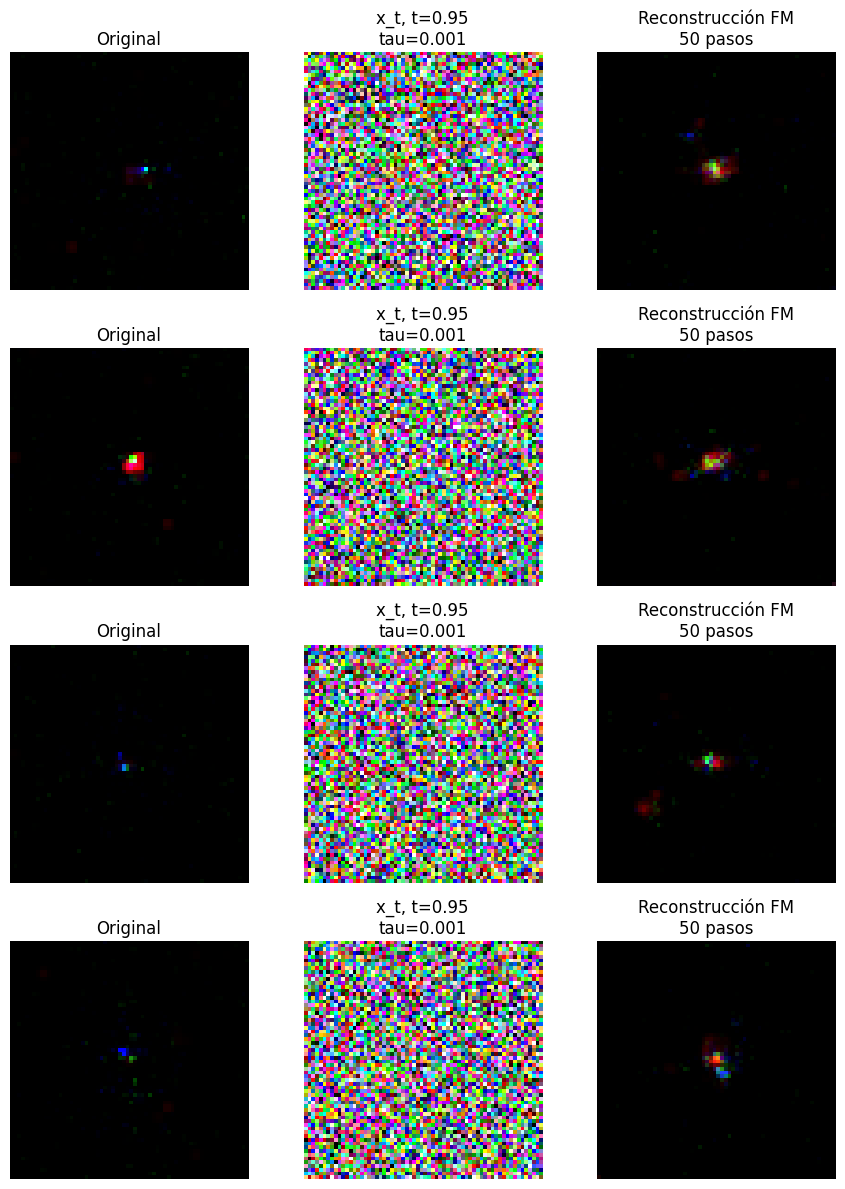

RECONSTRUCCIÓN FLOW MATCHING DESDE t_start=0.9
num_timesteps: 1000
t_start modelo: 0.9
tau_start normalizado: 0.000901
num_steps integración: 50
Número de puntos temporales: 51
MSE reconstrucción: 0.003842


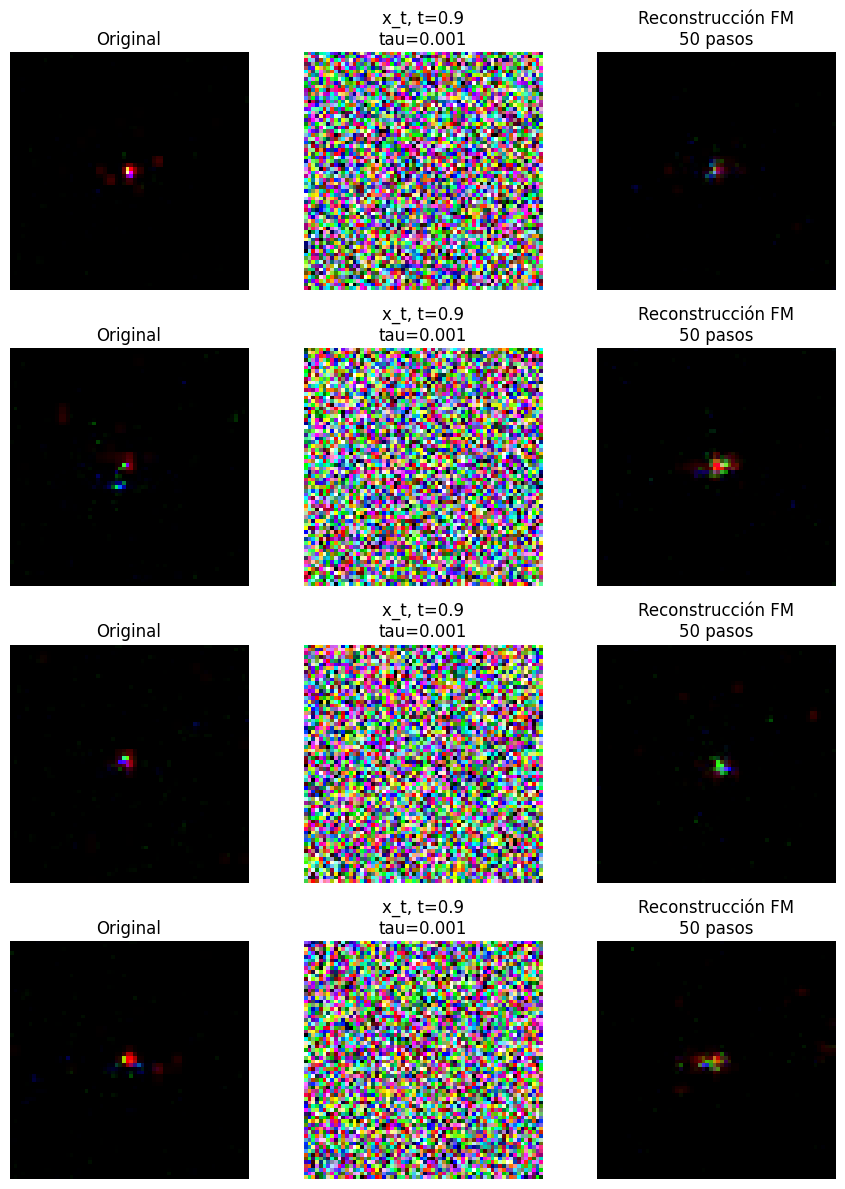

RECONSTRUCCIÓN FLOW MATCHING DESDE t_start=0.8
num_timesteps: 1000
t_start modelo: 0.8
tau_start normalizado: 0.000801
num_steps integración: 50
Número de puntos temporales: 51
MSE reconstrucción: 0.003416


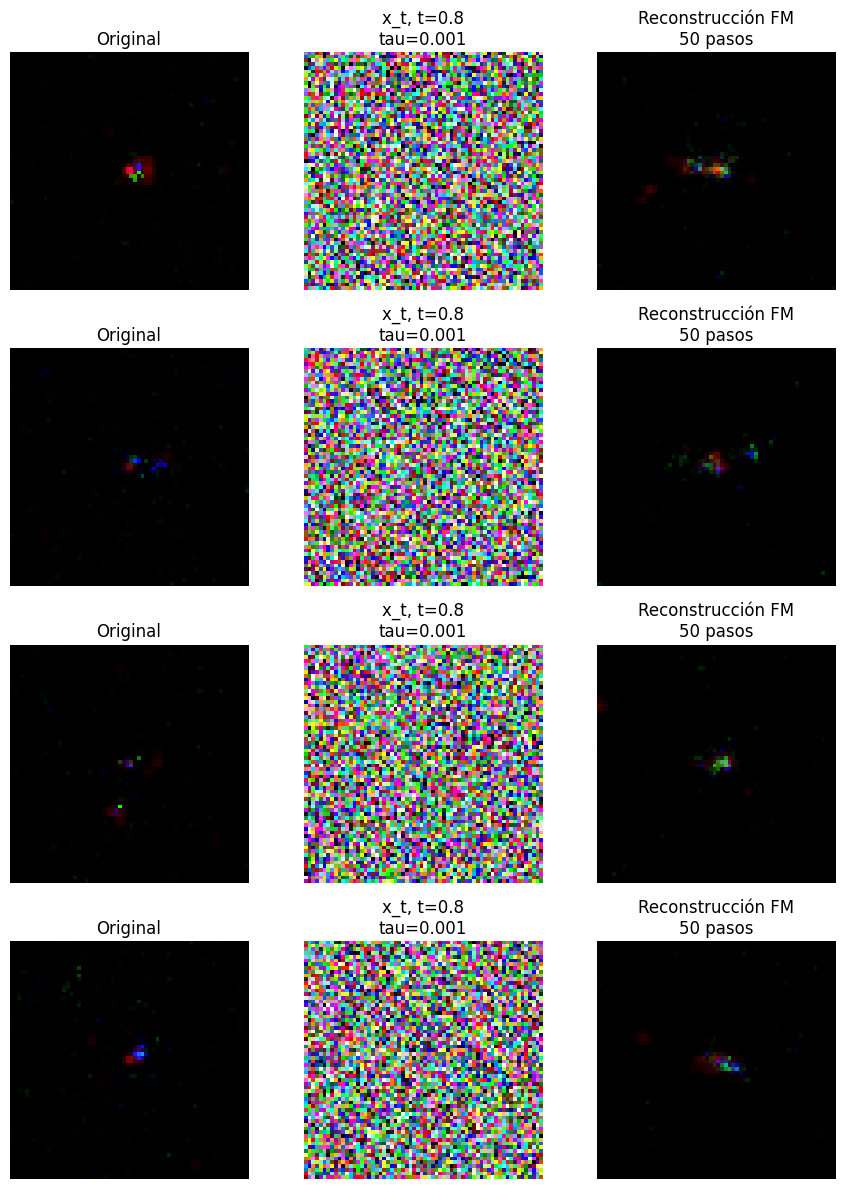

RECONSTRUCCIÓN FLOW MATCHING DESDE t_start=0.7
num_timesteps: 1000
t_start modelo: 0.7
tau_start normalizado: 0.000701
num_steps integración: 50
Número de puntos temporales: 51
MSE reconstrucción: 0.003111


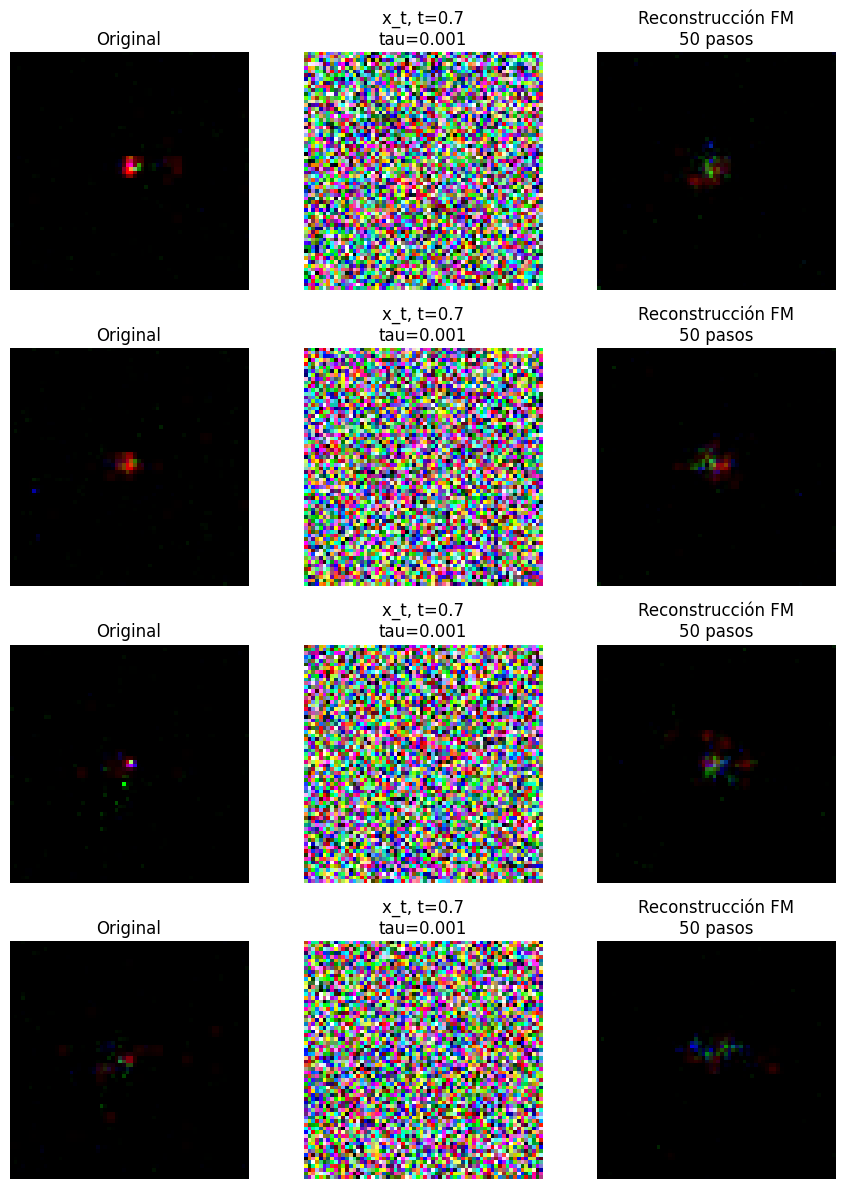

RECONSTRUCCIÓN FLOW MATCHING DESDE t_start=0.6
num_timesteps: 1000
t_start modelo: 0.6
tau_start normalizado: 0.000601
num_steps integración: 50
Número de puntos temporales: 51
MSE reconstrucción: 0.004989


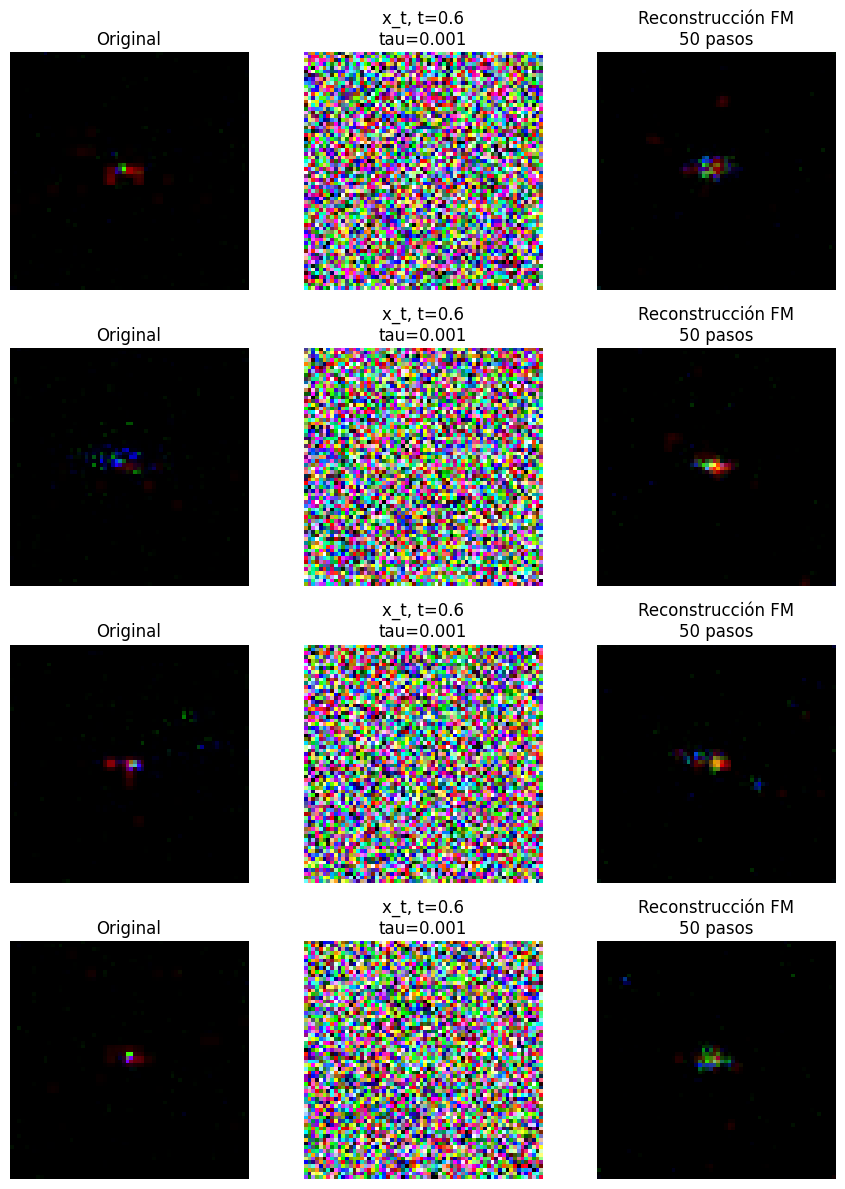

RECONSTRUCCIÓN FLOW MATCHING DESDE t_start=0.5
num_timesteps: 1000
t_start modelo: 0.5
tau_start normalizado: 0.000501
num_steps integración: 50
Número de puntos temporales: 51
MSE reconstrucción: 0.004197


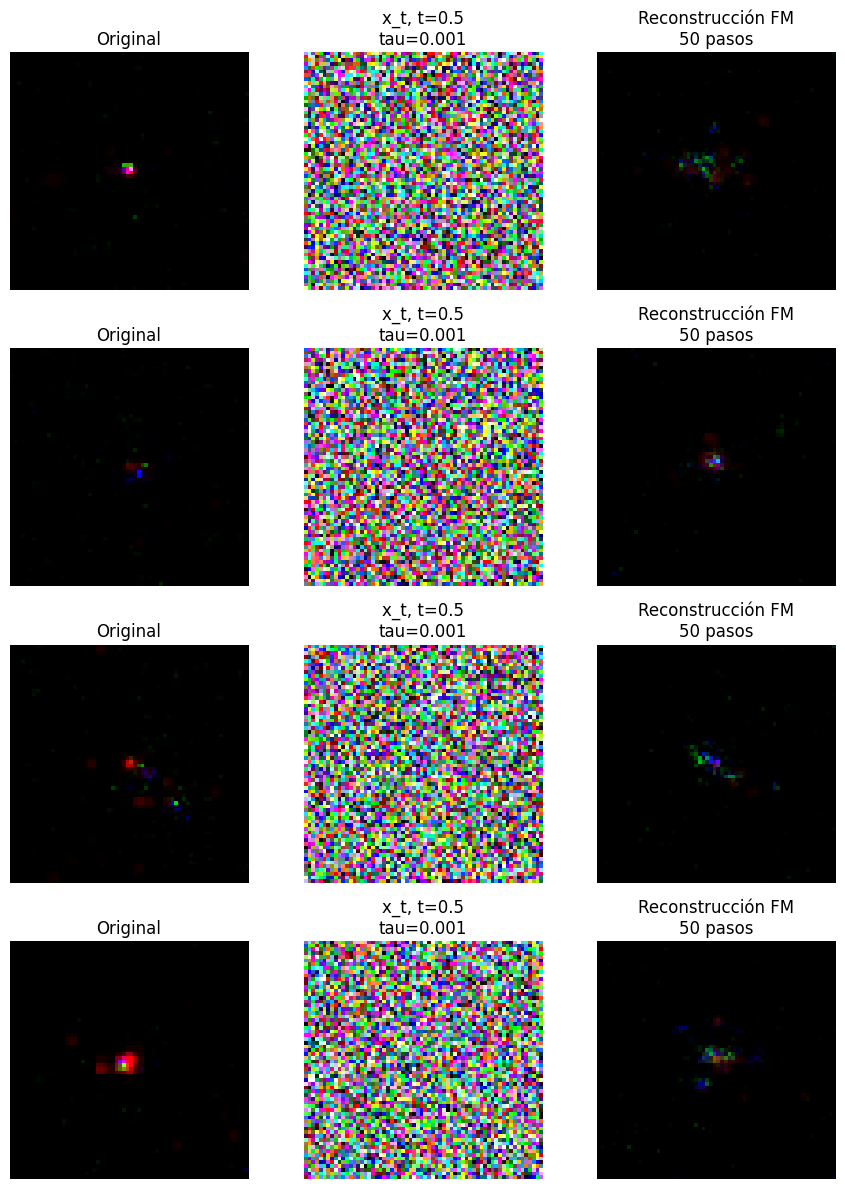

RECONSTRUCCIÓN FLOW MATCHING DESDE t_start=0.1
num_timesteps: 1000
t_start modelo: 0.1
tau_start normalizado: 0.000100
num_steps integración: 50
Número de puntos temporales: 51
MSE reconstrucción: 0.005375


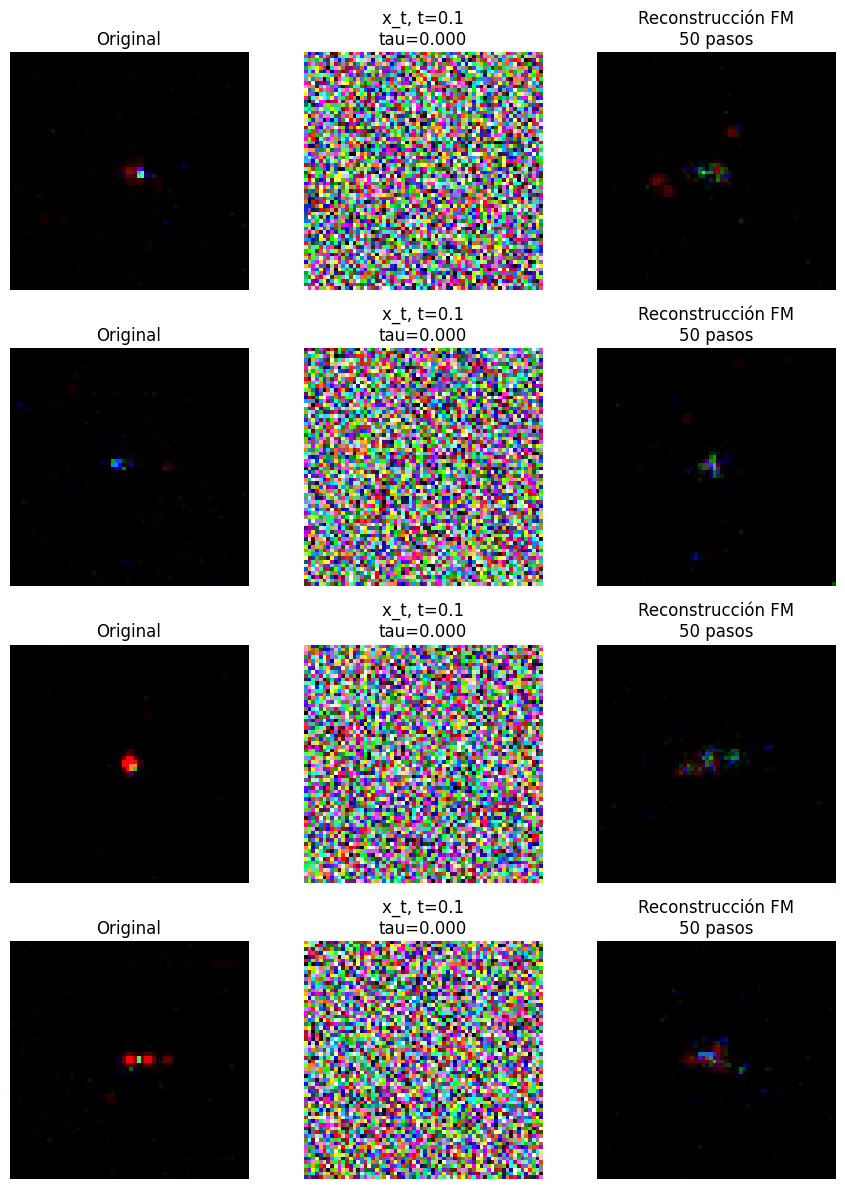

In [71]:
recon_095 = reconstruccion_iterativa_desde_xt_fm(
    modelo_entrenado, scheduler, train_loader, device, t_start=0.95, n=4, num_steps=50, mostrar=True,
    contrast=False,
)
recon_090 = reconstruccion_iterativa_desde_xt_fm(
    modelo_entrenado, scheduler, train_loader, device, t_start=0.9, n=4, num_steps=50, mostrar=True,
    contrast=False,
)
recon_080 = reconstruccion_iterativa_desde_xt_fm(
    modelo_entrenado, scheduler, train_loader, device, t_start=0.8, n=4, num_steps=50, mostrar=True,
    contrast=False,
)
recon_070 = reconstruccion_iterativa_desde_xt_fm(
    modelo_entrenado, scheduler, train_loader, device, t_start=0.7, n=4, num_steps=50, mostrar=True,
    contrast=False,
)
recon_060 = reconstruccion_iterativa_desde_xt_fm(
    modelo_entrenado, scheduler, train_loader, device, t_start=0.6, n=4, num_steps=50, mostrar=True,
    contrast=False,
)
recon_050 = reconstruccion_iterativa_desde_xt_fm(
    modelo_entrenado, scheduler, train_loader, device, t_start=0.5, n=4, num_steps=50, mostrar=True,
    contrast=False,
)
recon_010 = reconstruccion_iterativa_desde_xt_fm(
    modelo_entrenado, scheduler, train_loader, device, t_start=0.1, n=4, num_steps=50, mostrar=True,
    contrast=False,
)

In [75]:
@torch.no_grad()
def resumen_intensidades_pixeles(x, nombre='imagen', thresholds=None, eps=1e-12):
    if thresholds is None:
        thresholds = [0.0, 1e-06, 1e-05, 0.0001, 0.0005, 0.001, 0.005, 0.01]

    x = to_01(x).detach().float().cpu()
    pix = x.reshape(-1)
    datos = {}
    datos[f'{nombre}_min'] = pix.min().item()
    datos[f'{nombre}_max'] = pix.max().item()
    datos[f'{nombre}_mean'] = pix.mean().item()
    datos[f'{nombre}_std'] = pix.std().item()

    for q in [0.5, 0.9, 0.95, 0.99, 0.995, 0.999]:
        datos[f'{nombre}_q{q}'] = torch.quantile(pix, q).item()

    datos[f'{nombre}_frac_exact_zero'] = (pix <= eps).float().mean().item()

    for thr in thresholds:
        datos[f'{nombre}_frac_gt_{thr:g}'] = (pix > thr).float().mean().item()
        datos[f'{nombre}_energy_gt_{thr:g}'] = pix[pix > thr].sum().item()

    df = pd.DataFrame.from_dict(datos, orient='index', columns=['valor'])
    display(df)

    return datos

In [76]:
@torch.no_grad()
def graficar_histograma_intensidades(x_real, x_pred, nombre_pred='Generada/Recons', bins=200, eps=1e-12, log_y=True):
    x_real = to_01(x_real).detach().float().cpu().reshape(-1)
    x_pred = to_01(x_pred).detach().float().cpu().reshape(-1)
    plt.figure(figsize=(8, 5))
    plt.hist(x_real.numpy(), bins=bins, alpha=0.5, density=True, label='Real')
    plt.hist(x_pred.numpy(), bins=bins, alpha=0.5, density=True, label=nombre_pred)

    if log_y:
        plt.yscale('log')

    plt.xlabel('Intensidad del píxel en escala [0, 1]')
    plt.ylabel('Densidad')
    plt.title('Histograma de intensidades de píxeles')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


@torch.no_grad()
def graficar_histograma_intensidades_positivas(x_real, x_pred, nombre_pred='Generada/Recons', bins=200, eps=1e-08, log_y=True):
    x_real = to_01(x_real).detach().float().cpu().reshape(-1)
    x_pred = to_01(x_pred).detach().float().cpu().reshape(-1)
    x_real_pos = x_real[x_real > eps]
    x_pred_pos = x_pred[x_pred > eps]

    plt.figure(figsize=(8, 5))
    plt.hist(x_real_pos.numpy(), bins=bins, alpha=0.5, density=True, label='Real > 0')
    plt.hist(x_pred_pos.numpy(), bins=bins, alpha=0.5, density=True, label=f'{nombre_pred} > 0')

    if log_y:
        plt.yscale('log')

    plt.xlabel('Intensidad del píxel en escala [0, 1]')
    plt.ylabel('Densidad')
    plt.title('Histograma de intensidades positivas')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [77]:
@torch.no_grad()
def aplicar_corte_pixeles(x, threshold):
    x = to_01(x).detach().clone()
    x[x < threshold] = 0.0

    return x

In [78]:
@torch.no_grad()
def evaluar_cortes_generacion(x_gen, x_real_ref, thresholds=None, num_bins=32):
    if thresholds is None:
        thresholds = [0.0, 1e-06, 1e-05, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

    x_gen = to_01(x_gen)
    x_real_ref = to_01(x_real_ref).to(x_gen.device)
    filas = []

    for thr in thresholds:
        x_gen_cut = aplicar_corte_pixeles(x_gen, thr).to(x_gen.device)
        obs_real = jet_observables(x_real_ref, active_thr=thr)
        obs_gen = jet_observables(x_gen_cut, active_thr=thr)
        fila = {
            'threshold': thr,
            'energy_real_mean': obs_real['energy'].mean().item(),
            'energy_gen_mean': obs_gen['energy'].mean().item(),
            'energy_ratio_gen_real': obs_gen['energy'].mean().item() / (obs_real['energy'].mean().item() + 1e-08),
            'active_frac_real_mean': obs_real['active_frac'].mean().item(),
            'active_frac_gen_mean': obs_gen['active_frac'].mean().item(),
            'active_frac_ratio_gen_real': obs_gen['active_frac'].mean().item() / (obs_real['active_frac'].mean().item() + 1e-08),
            'max_real_mean': obs_real['max_intensity'].mean().item(),
            'max_gen_mean': obs_gen['max_intensity'].mean().item(),
            'E_w1': w1_samples(obs_gen['energy'], obs_real['energy']),
            'active_frac_w1': w1_samples(obs_gen['active_frac'], obs_real['active_frac']),
            'max_intensity_w1': w1_samples(obs_gen['max_intensity'], obs_real['max_intensity']),
        }

        filas.append(fila)

    df = pd.DataFrame(filas)
    display(df)

    return df

In [79]:
@torch.no_grad()
def evaluar_reconstruccion_con_fondo(x_rec, x_real, active_thr=0.0001):
    x_rec = to_01(x_rec)
    x_real = to_01(x_real)
    active_real = x_real > active_thr
    background_real = x_real <= active_thr
    metricas = {}
    metricas['mse_total'] = F.mse_loss(x_rec, x_real).item()

    if active_real.sum() > 0:
        metricas['mse_en_pixeles_activos_reales'] = ((x_rec - x_real) ** 2)[active_real].mean().item()
        metricas['energia_real_activa'] = x_real[active_real].sum().item()
        metricas['energia_rec_en_activos_reales'] = x_rec[active_real].sum().item()
    else:
        metricas['mse_en_pixeles_activos_reales'] = np.nan
        metricas['energia_real_activa'] = np.nan
        metricas['energia_rec_en_activos_reales'] = np.nan

    if background_real.sum() > 0:
        metricas['mse_en_fondo_real'] = ((x_rec - x_real) ** 2)[background_real].mean().item()
        metricas['energia_falsa_en_fondo'] = x_rec[background_real].sum().item()
        metricas['intensidad_media_fondo_rec'] = x_rec[background_real].mean().item()
        metricas['frac_fondo_rec_mayor_thr'] = (x_rec[background_real] > active_thr).float().mean().item()
    else:
        metricas['mse_en_fondo_real'] = np.nan
        metricas['energia_falsa_en_fondo'] = np.nan
        metricas['intensidad_media_fondo_rec'] = np.nan
        metricas['frac_fondo_rec_mayor_thr'] = np.nan

    metricas['energia_real_total'] = x_real.sum().item()
    metricas['energia_rec_total'] = x_rec.sum().item()
    metricas['ratio_energia_rec_real'] = metricas['energia_rec_total'] / (metricas['energia_real_total'] + 1e-08)
    metricas['active_frac_real'] = active_real.float().mean().item()
    metricas['active_frac_rec'] = (x_rec > active_thr).float().mean().item()
    df = pd.DataFrame.from_dict(metricas, orient='index', columns=['valor'])

    display(df)

    return metricas

,valor
real_min,0.000000
real_max,1.000000
real_mean,0.002078
real_std,0.025677
real_q0.5,0.000000
real_q0.9,0.000000
real_q0.95,0.000000
real_q0.99,0.042533
real_q0.995,0.085529
real_q0.999,0.363097


,valor
generada_min,0.000000
generada_max,1.000000
generada_mean,0.002842
generada_std,0.030650
generada_q0.5,0.000000
generada_q0.9,0.000000
generada_q0.95,0.000000
generada_q0.99,0.073995
generada_q0.995,0.166153
generada_q0.999,0.496396


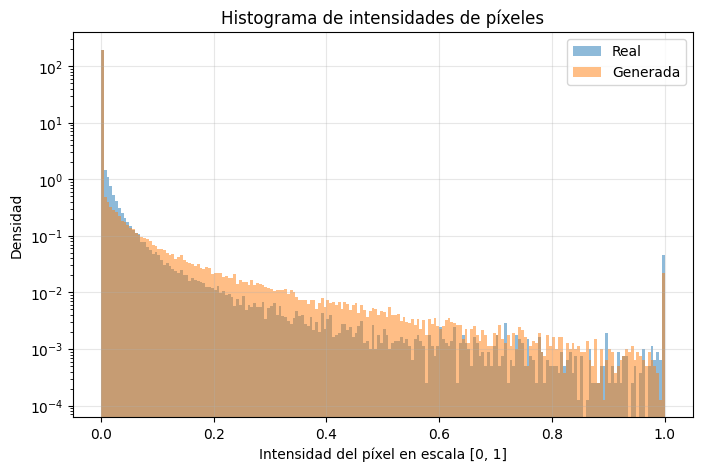

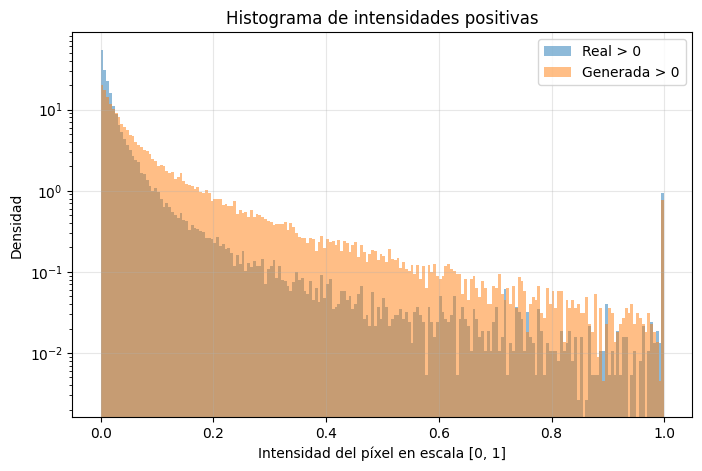

,threshold,energy_real_mean,energy_gen_mean,energy_ratio_gen_real,active_frac_real_mean,active_frac_gen_mean,active_frac_ratio_gen_real,max_real_mean,max_gen_mean,E_w1,active_frac_w1,max_intensity_w1
0,0.000000,25.535656,34.927578,1.367796,0.047846,0.028216,0.589728,0.939186,0.93504,9.391921,0.019630,0.036356
1,0.000001,25.535656,34.927578,1.367796,0.047846,0.028215,0.589715,0.939186,0.93504,9.391921,0.019630,0.036356
2,0.000010,25.535656,34.927578,1.367796,0.047825,0.028212,0.589899,0.939186,0.93504,9.391921,0.019613,0.036356
3,0.000100,25.535656,34.927540,1.367795,0.047497,0.028159,0.592871,0.939186,0.93504,9.391883,0.019337,0.036356
4,0.000500,25.535656,34.926620,1.367759,0.045886,0.027910,0.608255,0.939186,0.93504,9.390965,0.017975,0.036356
5,0.001000,25.535656,34.923912,1.367653,0.044214,0.027616,0.624606,0.939186,0.93504,9.388255,0.016598,0.036356
6,0.002000,25.535656,34.913490,1.367245,0.041354,0.027046,0.653993,0.939186,0.93504,9.377836,0.014314,0.036356
7,0.005000,25.535656,34.842327,1.364458,0.034801,0.025379,0.729269,0.939186,0.93504,9.306671,0.009492,0.036356
8,0.010000,25.535656,34.619450,1.355730,0.027404,0.022935,0.836902,0.939186,0.93504,9.083793,0.004791,0.036356
9,0.020000,25.535656,33.966362,1.330154,0.018141,0.019309,1.064379,0.939186,0.93504,8.437275,0.001815,0.036356


In [80]:
resumen_intensidades_pixeles(jets_real_eval, nombre='real')
resumen_intensidades_pixeles(jets_gen_eval, nombre='generada')
graficar_histograma_intensidades(jets_real_eval, jets_gen_eval, nombre_pred='Generada', bins=200, log_y=True)
graficar_histograma_intensidades_positivas(jets_real_eval, jets_gen_eval, nombre_pred='Generada', bins=200, log_y=True)

df_cortes_gen = evaluar_cortes_generacion(
    jets_gen_eval, jets_real_eval,
    thresholds=[0.0, 1e-06, 1e-05, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05], num_bins=32,
)

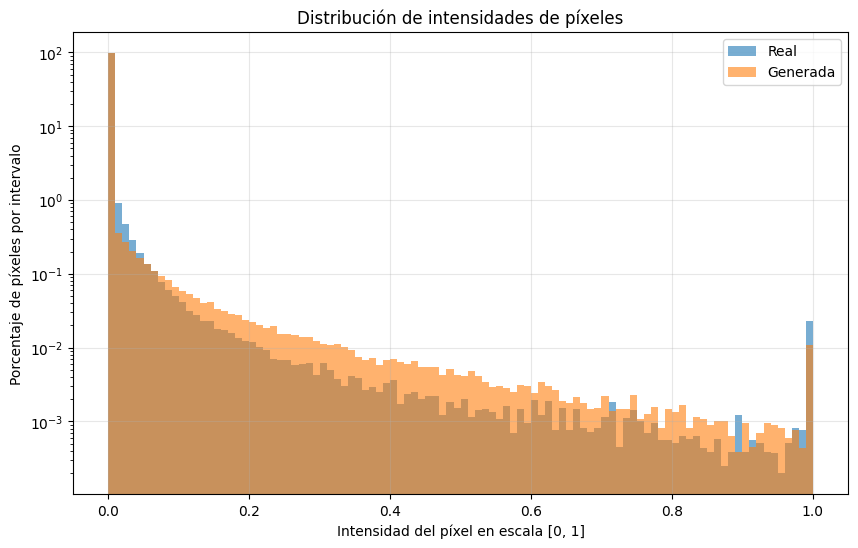

In [81]:
import numpy as np
import matplotlib.pyplot as plt
real = jets_real_eval.detach().cpu().numpy().ravel()
generada = jets_gen_eval.detach().cpu().numpy().ravel()
bins = np.linspace(0, 1, 101)
weights_real = np.ones_like(real) * 100.0 / len(real)
weights_gen = np.ones_like(generada) * 100.0 / len(generada)

plt.figure(figsize=(10, 6))
plt.hist(real, bins=bins, weights=weights_real, alpha=0.6, label='Real')
plt.hist(generada, bins=bins, weights=weights_gen, alpha=0.6, label='Generada')
plt.yscale('log')
plt.xlabel('Intensidad del píxel en escala [0, 1]')
plt.ylabel('Porcentaje de píxeles por intervalo')
plt.title('Distribución de intensidades de píxeles')
plt.legend()
plt.grid(alpha=0.3)
plt.show()